# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [109]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [110]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [111]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [112]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [113]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [114]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [115]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [116]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [117]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [118]:
# cantidad de nulos para users
print('Cantidad de valores nulos:')
print(users.isna().sum())
print()
# proporcion de nulos para users
print('Proporción de valores nulos:')
print(users.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [119]:
# cantidad de nulos para usage
print('Cantidad de valores nulos:')
print(usage.isna().sum())
print()
# proporcion de nulos para usage
print('Proporción de valores nulos:')
print(usage.isna().mean())

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  
  **Respuesta:** En el df 'users' solo la columnas 'city' y 'churn date' presentan valores faltantes entre el 1% y 8% respectivamente. Mientras que en el df 'usage' se observan valores faltantes en las columnas 'date', 'duration' y 'lenght'. Sus porcentajes estan dentro del ~1% al 5%. 
- Indica qué harías: ¿imputar, eliminar, ignorar?
  
  **Respuesta:** Para los faltantes de 'users' a city se recomienda imputar con informacion de columnas adyacentes o incluso dejar como nulos. Mientras que para 'churn_date' se recomienda investigar para imputar los valores faltantes. En cuanto al df 'usage', el caso de la columna 'date' se recomienda dejar como nulos pero para 'length'se recomienda investigar para imputar los faltantes al igual que para 'duration' ya que son las columnas que mas nulos muestran.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [120]:
# explorar columnas numéricas de users
columnas_numericas = ['user_id','age']
print(users[columnas_numericas].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id`**Respuesta:** Muestra valores altos, que pueden estar affectados por el formato que tiene cada user id.
- La columna `age` **Respuesta:** Mientras tanto podemos observar valores negativos (valores invalidos) en la columna que estan afectando la media y el minimo]

In [121]:
# explorar columnas numéricas de usage
usage_columnas_numericas = ['id', 'user_id','duration','length']
print(usage[usage_columnas_numericas].describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` **Respuesta:** demuestran que solo son identificadores de usuario, ya que muestran que estan completas y no tienen ningun valor invalido o nulo.
- Las columnas `duration` y `length` **Respuesta:** podrian estar afectadas por los valores faltantes que ya se han mencionado.

In [122]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` **Respuesta:** demuestra que hay valores faltantes y solo 7 valores unicos, esto puede estar alterado ya que vimos en .head que hay un sentinel '?'. Requiere limpieza.
- La columna `plan` **Respuesta:** no hay valores faltantes y solo cuenta con 2 valores unicos donde la frecuencia con la que aparece es mayor, debido a la poca variedad de opciones.

In [123]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` **Respuesta:** se encuentra completa y muestra que mas del 50% de los valores pertenecen a la categoria "text". Esto debido a la poca variedad de opciones.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
      **Respuesta:** La columna 'age' es la que muestra sentinels de manera evidente. Las columnas como city del df 'users' solo esta incompleta al igual que las columnas 'duration' y 'lenght' del df 'usage'.
- ¿Qué acción tomarías?
      **Respuesta:** Con la columna 'age' buscaria imputar el valor invalido usando la mediana para evitar afectar el analisis, pero dependiendo de su repeticion, bien podriamos hasta eliminarlo. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [124]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], format='%Y-%m-%d')

In [125]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], format='%Y-%m-%d')

In [126]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].value_counts().sort_index()

2022-01-01 00:00:00.000000000     1
2022-01-01 06:34:17.914478619     1
2022-01-01 13:08:35.828957239     1
2022-01-01 19:42:53.743435858     1
2022-01-02 02:17:11.657914478     1
                                 ..
2024-12-30 04:17:06.256564144     1
2024-12-30 10:51:24.171042768     1
2024-12-30 17:25:42.085521392     1
2024-12-31 00:00:00.000000000     1
2026-05-10 00:00:00.000000000    40
Name: reg_date, Length: 3961, dtype: int64

En `reg_date`, **Respuesta:** podemos observar que hay varios registros con fechas fuera del rango establecido al inicio del proyecto. Hay evidencia del año 2026 cuando el maximo es 2024.

In [127]:
# Revisar los años presentes en `date` de usage
usage['date'].value_counts().sort_values()

2024-06-16 13:26:59.770494262    1
2024-06-19 11:36:26.244656116    1
2024-03-22 13:40:21.150528763    1
2024-01-20 00:40:27.900697517    1
2024-05-22 18:24:56.377409434    1
                                ..
2024-05-14 20:15:08.302707566    1
2024-02-15 03:05:41.558538963    1
2024-03-08 10:17:20.606015150    1
2024-01-23 07:11:39.047476186    1
2024-04-08 01:44:47.917197929    1
Name: date, Length: 39950, dtype: int64

En `date`, **Respuesta:** los años de la columna se mantienen dentro del año 2024 y solo basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

   **Respuesta:** Si aparecen años sin transcurrir en 'reg_date' mientras que en 'date' los años estan dentro del rango a analizar.
- ¿Qué harías con ellas?

  **Respuesta:** Ya que el analisis solo corresponde de fechas anteriores hasta el 2024 podemos eliminar los registros con fechas que aun no han sucedido.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [128]:
# Reemplazar -999 por la mediana de age
age_mediana = 47
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [129]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [130]:
# Marcar fechas futuras como NA para reg_date
mask = users['reg_date'].dt.year == 2026
users.loc[mask,'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`. Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [131]:
# Verificación MAR en usage (Missing At Random) para duration
print("Análisis de nulos en 'duration' por tipo:")
usage['duration'].isna().groupby(usage['type']).mean()

Análisis de nulos en 'duration' por tipo:


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [132]:
# Verificación MAR en usage (Missing At Random) para length
print("Análisis de nulos en 'length' por tipo:")
usage['length'].isna().groupby(usage['type']).mean()

Análisis de nulos en 'length' por tipo:


type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`

**Respuesta:** Es logico dejar los nulos en ambas columnas ya que en contexto del negocio un mensaje de texto no puede tener duracion, pero si tiene longitud y viceversa para las llamadas. Ambos nulos son de tipo MAR

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [133]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage[['user_id','is_text','is_call','duration']].groupby('user_id').agg({'is_text':'sum', 'is_call':'sum', 'duration': 'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [134]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes','is_call':'cant_llamadas','duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [135]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg, users, on=['user_id'], how='left')
user_profile.head(5)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [136]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['cant_mensajes','cant_llamadas','cant_minutos_llamada','age']
print(user_profile[columnas_numericas].describe())

       cant_mensajes  cant_llamadas  cant_minutos_llamada          age
count    3999.000000    3999.000000           3999.000000  3999.000000
mean        5.524381       4.478120             23.317054    48.124531
std         2.358416       2.144238             18.168095    17.692032
min         0.000000       0.000000              0.000000    18.000000
25%         4.000000       3.000000             11.120000    33.000000
50%         5.000000       4.000000             19.780000    47.000000
75%         7.000000       6.000000             31.415000    63.000000
max        17.000000      15.000000            155.690000    79.000000


In [138]:
# Distribución porcentual del tipo de plan
plan_distribution = user_profile['plan'].value_counts(normalize=True) * 100
print('Disctribucion porcentual por tipo de plan')
print(plan_distribution)

Disctribucion porcentual por tipo de plan
Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

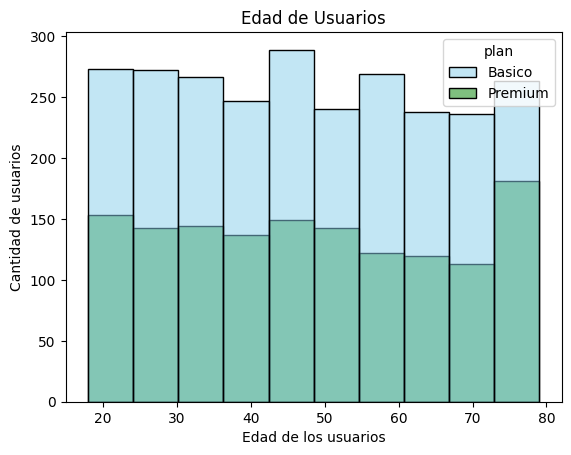

In [153]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', bins=10, palette=['skyblue','green'],hue='plan')

plt.xlabel('Edad de los usuarios')
plt.ylabel('Cantidad de usuarios')
plt.title('Edad de Usuarios')
plt.show()

💡Insights: 
- La distribucion observada es un tanto simetrica pues la mayoria de los usuarios se encuentran en el rango de edad de 40-50 años. Conforme su edad incrementa, tienden a hacer mas uso del plan basico. A excepcion de los mayores de 70 quienes tienen planes premium.

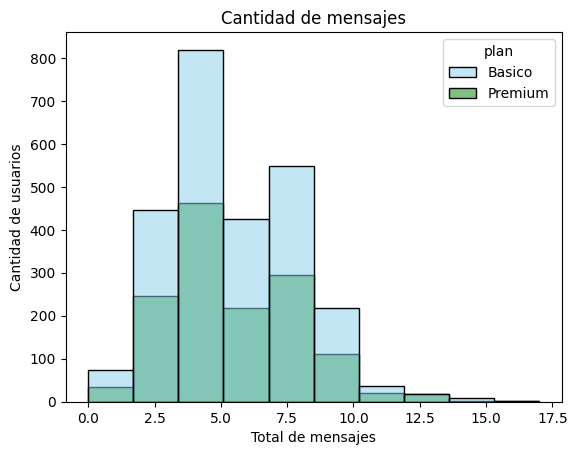

In [154]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=10, palette=['skyblue','green'], hue='plan')
plt.xlabel('Total de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de mensajes')
plt.show()

💡Insights: 
- Aqui podemos observar un sesgo a la derecha. La mayoria de los usuarios tanto del plan basico como el premium tienden a enviar pocos mensajes. Sin embargo se aprecia una cantidad de usuarios de plan basico que mandan mas de 10 mensajes. Seria prudente identificar a estos usuarios.

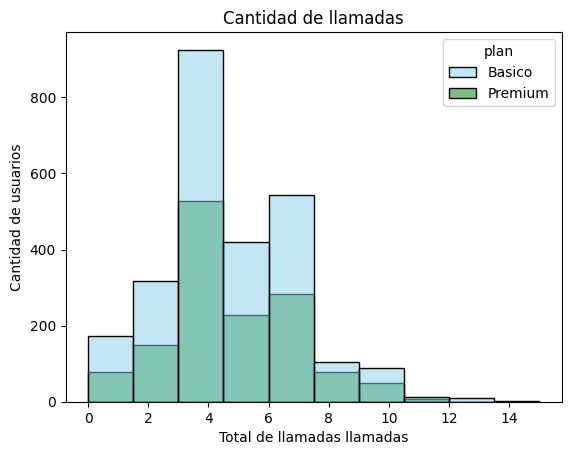

In [155]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=10, palette=['skyblue','green'],hue='plan')
plt.xlabel('Total de llamadas llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de llamadas')
plt.show()

💡Insights: 
- Distribución hacia la derecha. Similiar a la cantidad de mensajes. La mayoria de usuarios tienden a hacer menos de 4 llamadas. Sin embargo hay un pequeño grupo que usuarios del plan basico que hacen mas llamadas de lo normal. 

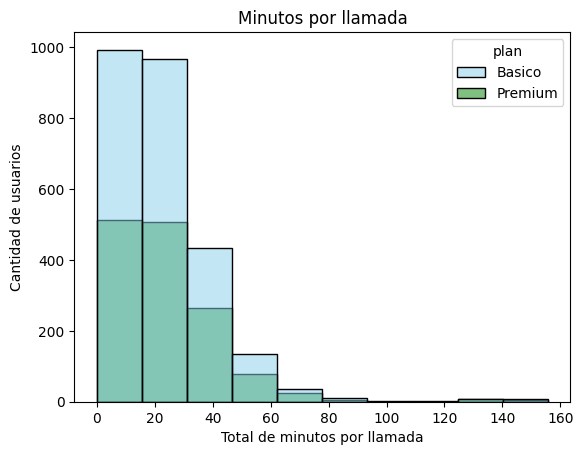

In [156]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=10, palette=['skyblue','green'],hue='plan')
plt.xlabel('Total de minutos por llamada')
plt.ylabel('Cantidad de usuarios')
plt.title('Minutos por llamada')
plt.show()

💡Insights: 
- La distribucion de la duracion de las llamadas es similar a la cantidad de llamadas que hacen los usuarios. Una gran mayoria de usuarios parece usar menos de 30 minutos en sus llamadas. A diferencia de las graficas anteriores aqui se puede apreciar que hay un pequeño grupo de usuarios premium que hacen llamadas de larga duracion. Valdria la pena investigar e identificar a este grupo, pues hacen que el sesgo sea hacia la derecha.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

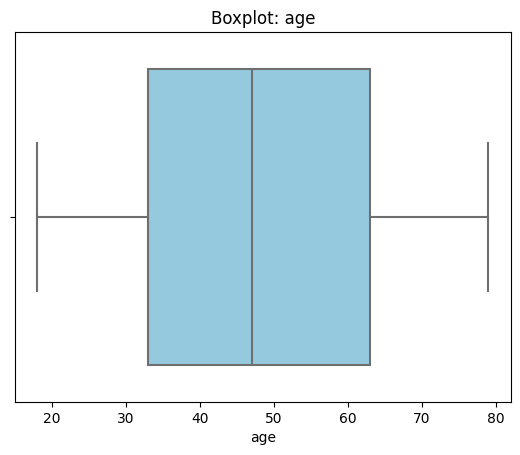

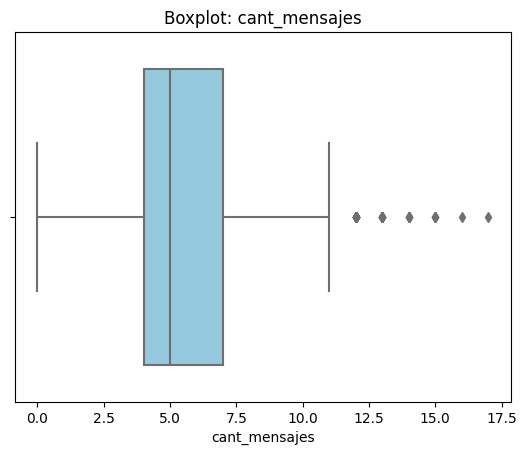

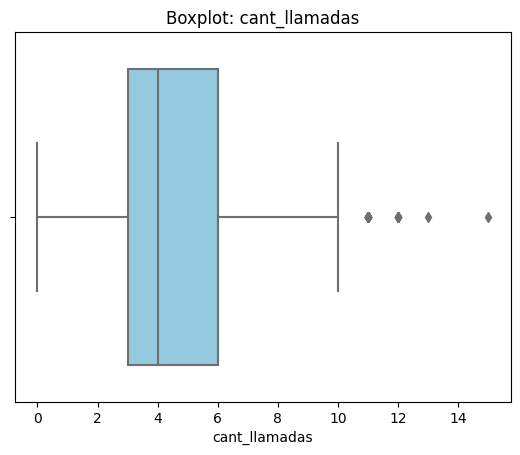

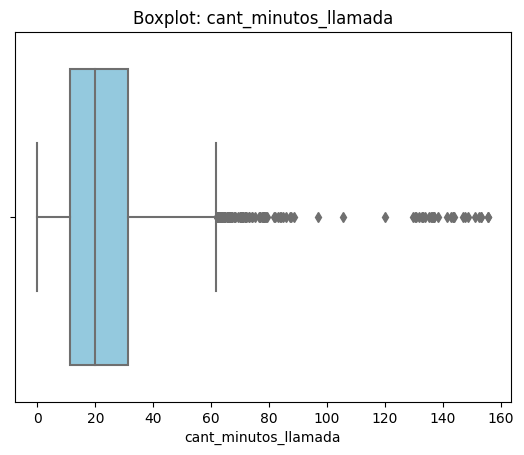

In [158]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas :
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers. Una distribucion simetrica y predecible.
- cant_mensajes: Presenta outliers. Y un sesgo hacia la derecha.
- cant_llamadas: Presenta una cantidad menor de outliers y un sesgo hacia la derecha.
- cant_minutos_llamada: Muestra multiples outliers. Requiere analisis.

In [159]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites: 
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    print((f'{col}:límite superior = {upper:.2f}'))



age:límite superior = 108.00
cant_mensajes:límite superior = 11.50
cant_llamadas:límite superior = 10.50
cant_minutos_llamada:límite superior = 61.86


In [162]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.124531,5.524381,4.478120,23.317054
std,17.692032,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?

    **Respuesta:** Seria recomendable mantenerlos, ya que son pocos clientes que no afectan a las metricas y son comportamientos reales.
- cant_llamadas: mantener o no outliers, porqué?

    **Respuesta:** Seria recomendable mantenerlos, ya que son pocos clientes que no afectan a las metricas y son comportamientos reales.
- cant_minutos_llamada: mantener o no outliers, porqué?

    **Respuesta:** Seria mejor eliminar los outliers, pues distorcionan el análisis sin aportar interpretacion real. De ser necesario podriamos winsorizarlos si es que se requiere un analisis mas a detalle.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [163]:
# Crear columna grupo_uso
def level_use(row) :
    message = row['cant_mensajes']
    call = row['cant_llamadas']
    if pd.isna(message) or pd.isna(call):
        return "Error en Datos"
    if call < 5 and message < 5:
        return 'Bajo uso'
    elif call < 10 and message <10:
        return 'Uso medio'
    else:
        return 'Alto uso'
user_profile['grupo_uso'] = user_profile.apply(level_use, axis=1)

In [164]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [165]:
# Crear columna grupo_edad
def etapa_edad (row) :
    age_stage = row['age']
    if pd.isna(age_stage):
        return "Error en Datos"
    if age_stage < 30:
        return 'Joven'
    elif age_stage < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
user_profile['grupo_edad'] = user_profile.apply(etapa_edad, axis=1)

In [166]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

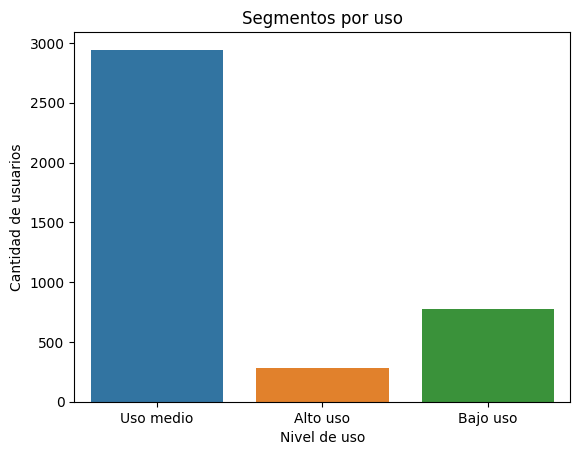

In [168]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Segmentos por uso')
plt.xlabel('Nivel de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

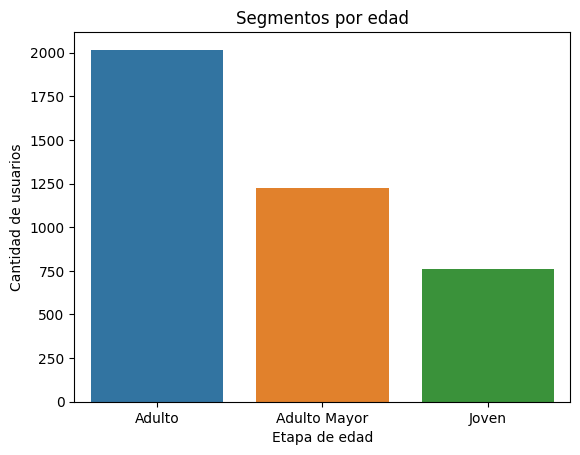

In [170]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Segmentos por edad')
plt.xlabel('Etapa de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Habia valores nulos e invalidos en ciertas columnas. Age, date, city. Se convirtieron en NaN o NaT dependiendo el caso. Sin embargo se pudo comprobar que ciertos nulos dependian directamente de otras columnas y se mantuvieron. 
- Columnas como reg_date y date estaban como float64, se tuvo que convertir a fecha para poder analizar los datos por año.


🔍 **Segmentos por Edad**
- Se clasificarion 3 segmentos de edades. En donde el "adulto" predomina en cuanto a uso y numero total de usuarios.
- Sin embargo el segmento "adulto mayor" a pesar de ser una cantidad considerable de usuarios, no hacen mucho uso de los servicios.


📊 **Segmentos por Nivel de Uso**
- La mayoria de los usuarios hacen un uso medio de los servicios que tienen. 
- A pesar de que hay pocos usuarios que hacen un alto uso, este grupo modifica el analisis pues su uso esta por encima de los limites, bien puede ser algo de una sola vez, pero si se repitiera el patron, seria recomendable identificarlos.


➡️ Esto sugiere que ...
El segmento que mas aporta es el grupo de adultos los cuales tienden a hacer un uso moderado de los servicios. Por otro lado a pesar de que un numero considerable de "adultos mayores" existe su uso de los servicios es bajo.

💡 **Recomendaciones**
- Se recomienda identificar al grupo pequeño de usuarios que hace un uso alto del servicio para darles tratamiento VIP.
- Adicionalmente se recomienda hablar con el equipo de marketing, para incentivar al segmento de jovenes, ya que mantienen un balance de uso y usuarios. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`